# Bloomberg Rates RV Notebook: Spreads + Curve Trades

**Purpose.** This notebook builds a clean rates-desk style relative-value framework for:

- **Slope trades** such as `2s5s`, `2s10s`, `5s30s`
- **Curve / butterfly trades** such as `2s5s10s`, `5s10s20s`, `5s10s30s`

It pulls Treasury yield data from Bloomberg through `xbbg`, computes multiple richness/cheapness measures, runs no-lookahead mean-reversion diagnostics, and produces restrained institutional-style charts suitable for a trader screen.

The notebook is intentionally modular: edit the Bloomberg tickers, fields, and trade definitions in the configuration cells without rewriting the engine.

> **Bloomberg requirement:** run this on a machine with Bloomberg Desktop/API access and the correct entitlements. The notebook includes a synthetic fallback for development only. On the desk, set `DEMO_IF_BLOOMBERG_FAILS = False`.

## Method overview

For each trade value \(X_t\), the notebook computes:

1. **Raw rolling z-score**

\[
z_t = \frac{X_t - \mu_t}{\sigma_t}
\]

2. **Historical percentile rank** over the rolling window.

3. **Nelson-Siegel fitted-curve residual**: fit a smooth cross-sectional yield curve each day, then compare the trade value implied by actual yields versus fitted yields.

4. **PCA fitted-curve residual**: use a rolling no-lookahead PCA reconstruction of the yield curve and compare actual trade value versus PCA-fitted trade value.

5. **Carry / roll-down proxy**: approximate how the trade changes if the current curve is unchanged and each tenor rolls down the curve over a selected horizon.

6. **Repo / liquidity overlays** where Bloomberg data is available.

7. **Mean-reversion diagnostics**: signal hit rate, average convergence, error-correction beta, and correlation between signal direction and future convergence.

The goal is not to mechanically trade every 2-sigma move. The goal is to separate:

- statistically unusual,
- model-confirmed,
- liquid/tradable,
- carry-supported,
- and historically mean-reverting.

## 0. Install notes

Run this once in your environment if needed:

```bash
pip install pandas numpy scipy scikit-learn statsmodels matplotlib xbbg blpapi
```

Bloomberg's `blpapi` installation can be environment-specific. If `pip install blpapi` fails, install it using the Bloomberg-provided package/index according to your firm's setup.

In [1]:
# Core imports
import warnings
warnings.filterwarnings("ignore")

from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
from datetime import date, timedelta

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap

from scipy.optimize import minimize
from scipy.interpolate import interp1d, CubicSpline
from scipy import stats

from sklearn.decomposition import PCA

try:
    import statsmodels.api as sm
    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
# -------------------------------------------------------------------
# Professional chart styling: restrained dark trader-screen aesthetic
# -------------------------------------------------------------------

TRADER = {
    "bg": "#0b0f14",
    "panel": "#111820",
    "grid": "#2b3542",
    "text": "#d7dde5",
    "muted": "#8f9bad",
    "line": "#d7dde5",
    "line2": "#80aaff",
    "line3": "#d5a253",
    "rich": "#e05f5f",
    "cheap": "#50b878",
    "neutral": "#7f8a99",
    "band": "#313c4a",
}

plt.rcParams.update({
    "figure.facecolor": TRADER["bg"],
    "axes.facecolor": TRADER["panel"],
    "axes.edgecolor": TRADER["grid"],
    "axes.labelcolor": TRADER["text"],
    "xtick.color": TRADER["muted"],
    "ytick.color": TRADER["muted"],
    "text.color": TRADER["text"],
    "axes.titlecolor": TRADER["text"],
    "grid.color": TRADER["grid"],
    "grid.alpha": 0.5,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 130,
    "savefig.dpi": 180,
})


def style_ax(ax, title=None, ylabel=None, xlabel=None):
    ax.grid(True, linewidth=0.6, alpha=0.45)
    for spine in ax.spines.values():
        spine.set_color(TRADER["grid"])
    if title:
        ax.set_title(title, loc="left", pad=10)
    if ylabel:
        ax.set_ylabel(ylabel)
    if xlabel:
        ax.set_xlabel(xlabel)
    ax.tick_params(axis="both", which="major", labelsize=9)
    return ax

## 1. Configuration

### Bloomberg ticker mapping

The default mapping uses generic U.S. Treasury yield indices such as `USGG2YR Index`. These are usually the easiest way to build slope/fly intuition.

If your desk wants cash-bond CUSIP-level RV, replace this mapping with specific Treasury securities and pull `YLD_YTM_MID` or price/yield fields.

In [3]:
# -------------------------------------------------------------------
# Main Bloomberg config
# -------------------------------------------------------------------

DEMO_IF_BLOOMBERG_FAILS = True   # On the desk, set False so failures are visible.
START_DATE = "2022-01-01"
END_DATE = pd.Timestamp.today().strftime("%Y-%m-%d")

# Generic U.S. Treasury yield indices. Verify with Bloomberg FLDS <GO> if needed.
YIELD_TICKERS = {
    2:  "USGG2YR Index",
    3:  "USGG3YR Index",
    5:  "USGG5YR Index",
    7:  "USGG7YR Index",
    10: "USGG10YR Index",
    20: "USGG20YR Index",
    30: "USGG30YR Index",
}

HIST_YIELD_FIELD = "PX_LAST"
LIVE_YIELD_FIELDS = ["PX_LAST", "PX_BID", "PX_ASK"]

# Optional repo/funding tickers. These are deliberately left editable because repo indices vary by desk entitlement.
# You can add sector-specific repo series if your desk has them.
# Example structure:
# REPO_TICKERS = {"GC": "<your GC repo ticker>", "SOFR": "SOFRRATE Index", 10: "<10y specific collateral repo series>"}
REPO_TICKERS = {
    # "SOFR": "SOFRRATE Index",
    # "GC": "GCFTRADE Index",
    # 10: "<10y specific collateral repo series>",
}
REPO_FIELD = "PX_LAST"

# Optional auction calendar. Populate manually or pull from your desk's auction data source.
# Expected columns: auction_date, sector, note
AUCTION_CALENDAR = pd.DataFrame(columns=["auction_date", "sector", "note"])
# Example:
# AUCTION_CALENDAR = pd.DataFrame([
#     {"auction_date": "2026-06-18", "sector": 20, "note": "20Y reopening"},
# ])
# AUCTION_CALENDAR["auction_date"] = pd.to_datetime(AUCTION_CALENDAR["auction_date"])

In [4]:
# -------------------------------------------------------------------
# Trade definitions
# Sign conventions:
# - Spreads: long tenor minus short tenor, e.g. 2s5s = y5 - y2.
# - Flies: belly minus weighted wings, e.g. 5s10s20s = y10 - 0.5*y5 - 0.5*y20.
#
# Higher yield = cheaper bond/rate sector.
# Therefore:
# - Positive fly residual => belly yield high vs wings => belly cheap.
# - Negative fly residual => belly yield low vs wings => belly rich.
# -------------------------------------------------------------------

SPREAD_TRADES = {
    "2s5s":   {2: -1.0, 5:  1.0},
    "2s10s":  {2: -1.0, 10: 1.0},
    "5s10s":  {5: -1.0, 10: 1.0},
    "5s30s":  {5: -1.0, 30: 1.0},
    "10s30s": {10:-1.0, 30: 1.0},
}

CURVE_TRADES = {
    "2s5s10s":    {2: -0.5, 5: 1.0, 10: -0.5},
    "3s7s10s":    {3: -0.5, 7: 1.0, 10: -0.5},
    "5s10s20s":   {5: -0.5, 10: 1.0, 20: -0.5},
    "5s10s30s":   {5: -0.5, 10: 1.0, 30: -0.5},
    "10s20s30s":  {10:-0.5, 20: 1.0, 30: -0.5},
    "2s10s30s":   {2: -0.5, 10: 1.0, 30: -0.5},
}

ALL_TRADES = {**SPREAD_TRADES, **CURVE_TRADES}
TRADE_TYPES = {name: "spread" for name in SPREAD_TRADES}
TRADE_TYPES.update({name: "curve" for name in CURVE_TRADES})

ROLLING_WINDOW = 252       # approx 1 trading year
PCA_WINDOW = 252
PCA_COMPONENTS = 3
ZSCORE_THRESHOLD = 1.5
HORIZONS = [5, 10, 20]     # trading days for mean reversion diagnostics
ROLLDOWN_HORIZON_MONTHS = 3

## 2. Bloomberg data pulls

This section uses `xbbg` for `bdh` and `bdp`-style calls. If Bloomberg is unavailable and `DEMO_IF_BLOOMBERG_FAILS = True`, the notebook creates realistic synthetic yield curves so you can still test the analytics and charts.

In [5]:
def _flatten_bbg_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Flatten common xbbg output formats into one-level columns."""
    if isinstance(df.columns, pd.MultiIndex):
        # For bdh(tickers=list, flds='PX_LAST'), xbbg usually returns MultiIndex columns: ticker, field
        if df.columns.nlevels >= 2:
            # Keep the ticker level if one field, otherwise join levels
            fields = list(df.columns.get_level_values(-1).unique())
            if len(fields) == 1:
                df = df.copy()
                df.columns = df.columns.get_level_values(0)
            else:
                df = df.copy()
                df.columns = ["|".join(map(str, c)) for c in df.columns]
    return df


def pull_bloomberg_yields(
    tickers_by_tenor: Dict[int, str],
    start_date: str,
    end_date: str,
    field: str = "PX_LAST",
) -> pd.DataFrame:
    """Pull historical yield panel from Bloomberg and return columns as numeric tenors."""
    from xbbg import blp
    tickers = list(tickers_by_tenor.values())
    tenor_by_ticker = {v: k for k, v in tickers_by_tenor.items()}
    raw = blp.bdh(tickers=tickers, flds=field, start_date=start_date, end_date=end_date)
    raw = _flatten_bbg_columns(raw)
    raw = raw.rename(columns=tenor_by_ticker)
    raw = raw[[c for c in sorted(raw.columns) if c in tickers_by_tenor]]
    raw.index = pd.to_datetime(raw.index)
    raw = raw.apply(pd.to_numeric, errors="coerce").sort_index().dropna(how="all")
    return raw


def pull_bloomberg_live_snapshot(
    tickers_by_tenor: Dict[int, str],
    fields: List[str],
) -> pd.DataFrame:
    """Pull current Bloomberg snapshot for generic yield indices."""
    from xbbg import blp
    tickers = list(tickers_by_tenor.values())
    tenor_by_ticker = {v: k for k, v in tickers_by_tenor.items()}
    raw = blp.bdp(tickers=tickers, flds=fields)
    raw = raw.copy()
    raw.index = [tenor_by_ticker.get(idx, idx) for idx in raw.index]
    raw.index.name = "tenor"
    raw = raw.apply(pd.to_numeric, errors="coerce")
    return raw.sort_index()


def pull_optional_repo(repo_tickers: Dict, start_date: str, end_date: str, field: str = "PX_LAST") -> pd.DataFrame:
    """Pull optional repo/funding series if configured."""
    if not repo_tickers:
        return pd.DataFrame()
    from xbbg import blp
    tickers = list(repo_tickers.values())
    key_by_ticker = {v: k for k, v in repo_tickers.items()}
    raw = blp.bdh(tickers=tickers, flds=field, start_date=start_date, end_date=end_date)
    raw = _flatten_bbg_columns(raw)
    raw = raw.rename(columns=key_by_ticker)
    raw.index = pd.to_datetime(raw.index)
    return raw.apply(pd.to_numeric, errors="coerce").sort_index()


def make_demo_yields(start_date="2019-01-01", end_date=None, seed=7) -> pd.DataFrame:
    """Synthetic yield curves with level/slope/curvature regimes for offline development only."""
    if end_date is None:
        end_date = pd.Timestamp.today().strftime("%Y-%m-%d")
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range(start=start_date, end=end_date)
    tenors = np.array(sorted(YIELD_TICKERS.keys()), dtype=float)
    n = len(dates)

    level = np.zeros(n)
    slope = np.zeros(n)
    curve = np.zeros(n)
    vol = np.ones(n) * 1.0

    # Regime changes to make z-scores and PCA realistic enough for chart testing.
    regime_break = int(n * 0.55)
    vol[regime_break:] = 1.7

    for t in range(1, n):
        level[t] = 0.997 * level[t-1] + rng.normal(0, 0.018 * vol[t])
        slope[t] = 0.985 * slope[t-1] + rng.normal(0, 0.012 * vol[t])
        curve[t] = 0.965 * curve[t-1] + rng.normal(0, 0.010 * vol[t])

    base = 2.25 + 0.90 * (1 - np.exp(-tenors / 7))
    slope_load = (tenors - tenors.mean()) / tenors.std()
    curve_load = -((tenors - 10) / 10) ** 2 + 0.6

    data = []
    for i in range(n):
        y = base + level[i] + 0.35 * slope[i] * slope_load + 0.22 * curve[i] * curve_load
        y += rng.normal(0, 0.012, len(tenors))
        data.append(y)
    df = pd.DataFrame(data, index=dates, columns=tenors.astype(int))
    return df.clip(lower=0.02)


def load_yields() -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, str]:
    """Load historical yields, live snapshot, and repo data."""
    source = "Bloomberg"
    try:
        hist_yields = pull_bloomberg_yields(YIELD_TICKERS, START_DATE, END_DATE, HIST_YIELD_FIELD)
        live_snapshot = pull_bloomberg_live_snapshot(YIELD_TICKERS, LIVE_YIELD_FIELDS)
        repo = pull_optional_repo(REPO_TICKERS, START_DATE, END_DATE, REPO_FIELD)
        if hist_yields.empty:
            raise RuntimeError("Bloomberg returned an empty historical yield panel.")
    except Exception as exc:
        if not DEMO_IF_BLOOMBERG_FAILS:
            raise
        print(f"Bloomberg pull failed; using synthetic demo data. Reason: {exc}")
        source = "Synthetic demo data"
        hist_yields = make_demo_yields(START_DATE, END_DATE)
        latest = hist_yields.iloc[-1]
        live_snapshot = pd.DataFrame({
            "PX_LAST": latest,
            "PX_BID": latest - 0.002,
            "PX_ASK": latest + 0.002,
        })
        live_snapshot.index.name = "tenor"
        repo = pd.DataFrame(index=hist_yields.index)
    return hist_yields, live_snapshot, repo, source

In [6]:
hist_yields, live_snapshot, repo_data, DATA_SOURCE = load_yields()

print(f"Data source: {DATA_SOURCE}")
print(f"Historical yield panel: {hist_yields.index.min().date()} to {hist_yields.index.max().date()}, shape={hist_yields.shape}")
display(hist_yields.tail())
display(live_snapshot)

Bloomberg pull failed; using synthetic demo data. Reason: No module named 'xbbg'
Data source: Synthetic demo data
Historical yield panel: 2022-01-03 to 2026-06-16, shape=(1162, 7)


tenor,2,3,5,7,10,20,30
2026-06-10,2.1440,2.2527,2.3940,2.5157,2.6297,2.8237,2.8643
2026-06-11,2.1361,2.2229,2.3837,2.4764,2.6536,2.7997,2.8610
2026-06-12,2.1391,2.2302,2.3892,2.4905,2.6114,2.7818,2.8489
2026-06-15,2.1373,2.2652,2.3777,2.4947,2.6317,2.8308,2.8512
2026-06-16,2.0876,2.2004,2.3541,2.4481,2.5673,2.7712,2.8630


,PX_LAST,PX_BID,PX_ASK
tenor,,,
2,2.0876,2.0856,2.0896
3,2.2004,2.1984,2.2024
5,2.3541,2.3521,2.3561
7,2.4481,2.4461,2.4501
10,2.5673,2.5653,2.5693
20,2.7712,2.7692,2.7732
30,2.8630,2.8610,2.8650


## 3. Core trade math

A trade is a linear combination of yields:

\[
X_t = \sum_i w_i y_{i,t}
\]

For example:

\[
2s5s = y_{5,t} - y_{2,t}
\]

\[
5s10s20s = y_{10,t} - \frac{1}{2}y_{5,t} - \frac{1}{2}y_{20,t}
\]

These values are in **percentage yield points** if Bloomberg yields are in percent. The notebook converts display values to **basis points** by multiplying by 100.

In [7]:
def compute_trade_series(yields: pd.DataFrame, weights: Dict[int, float]) -> pd.Series:
    """Compute linear trade value from yields in percent units."""
    missing = [tenor for tenor in weights if tenor not in yields.columns]
    if missing:
        raise KeyError(f"Missing tenors for trade: {missing}")
    out = pd.Series(0.0, index=yields.index)
    for tenor, w in weights.items():
        out = out + w * yields[tenor]
    return out.rename("trade")


def compute_all_trades(yields: pd.DataFrame, trades: Dict[str, Dict[int, float]]) -> pd.DataFrame:
    return pd.DataFrame({name: compute_trade_series(yields, w) for name, w in trades.items()})


def rolling_zscore(x: pd.Series, window: int = 252, min_periods: Optional[int] = None) -> pd.Series:
    if min_periods is None:
        min_periods = max(60, window // 3)
    mu = x.rolling(window, min_periods=min_periods).mean().shift(1)
    sig = x.rolling(window, min_periods=min_periods).std(ddof=1).shift(1)
    return ((x - mu) / sig).replace([np.inf, -np.inf], np.nan)


def rolling_percentile(x: pd.Series, window: int = 252, min_periods: Optional[int] = None) -> pd.Series:
    """No-lookahead rolling percentile of current observation against prior window."""
    if min_periods is None:
        min_periods = max(60, window // 3)
    vals = x.values
    out = np.full(len(vals), np.nan)
    for i in range(len(vals)):
        start = max(0, i - window)
        hist = vals[start:i]
        hist = hist[np.isfinite(hist)]
        if len(hist) >= min_periods and np.isfinite(vals[i]):
            out[i] = stats.percentileofscore(hist, vals[i], kind="rank")
    return pd.Series(out, index=x.index, name=x.name)


def robust_zscore(x: pd.Series, window: int = 252, min_periods: Optional[int] = None) -> pd.Series:
    """Rolling median/MAD z-score, useful when outliers distort standard deviation."""
    if min_periods is None:
        min_periods = max(60, window // 3)
    med = x.rolling(window, min_periods=min_periods).median().shift(1)
    mad = (x - med).abs().rolling(window, min_periods=min_periods).median().shift(1)
    return ((x - med) / (1.4826 * mad)).replace([np.inf, -np.inf], np.nan)

trade_values = compute_all_trades(hist_yields, ALL_TRADES)
trade_values_bps = trade_values * 100
trade_values_bps.tail()

,2s5s,2s10s,5s10s,5s30s,10s30s,2s5s10s,3s7s10s,5s10s20s,5s10s30s,10s20s30s,2s10s30s
2026-06-10,25.0007,48.5736,23.5728,47.0285,23.4556,0.7139,7.4513,2.0865,0.0586,7.6720,12.5590
2026-06-11,24.7583,51.7505,26.9922,47.7334,20.7412,-1.1169,3.8106,6.1914,3.1255,4.2388,15.5046
2026-06-12,25.0075,47.2268,22.2192,45.9686,23.7494,1.3942,6.9701,2.5872,-0.7651,5.1701,11.7387
2026-06-15,24.0440,49.4451,25.4011,47.3529,21.9518,-0.6785,4.6242,2.7451,1.7246,8.9349,13.7466
2026-06-16,26.6487,47.9723,21.3236,50.8935,29.5698,2.6625,6.4218,0.4707,-4.1231,5.5972,9.2012


## 4. Nelson-Siegel fitted curve and residuals

The Nelson-Siegel curve is:

\[
y(\tau) = \beta_0 + \beta_1\left(\frac{1-e^{-\tau/\lambda}}{\tau/\lambda}\right) + \beta_2\left(\frac{1-e^{-\tau/\lambda}}{\tau/\lambda} - e^{-\tau/\lambda}\right)
\]

For every date, the notebook fits \(\beta_0, \beta_1, \beta_2, \lambda\) across the available Treasury tenors and computes fitted trade values. The residual is:

\[
\epsilon^{NS}_{trade,t} = X_{actual,t} - X_{NS fitted,t}
\]

In [8]:
def ns_loadings(tau: np.ndarray, lam: float) -> Tuple[np.ndarray, np.ndarray]:
    tau = np.asarray(tau, dtype=float)
    x = tau / lam
    # Safe handling for tiny x
    f1 = np.where(np.abs(x) < 1e-8, 1.0, (1 - np.exp(-x)) / x)
    f2 = f1 - np.exp(-x)
    return f1, f2


def nelson_siegel_yield(tau: np.ndarray, beta0: float, beta1: float, beta2: float, lam: float) -> np.ndarray:
    f1, f2 = ns_loadings(tau, lam)
    return beta0 + beta1 * f1 + beta2 * f2


def fit_nelson_siegel_row(tenors: np.ndarray, yields: np.ndarray) -> Tuple[np.ndarray, Dict[str, float]]:
    """
    Fit NS curve for one cross-section. Returns fitted yields and parameters.

    Implementation detail: for speed/stability in a notebook, lambda is selected by grid search
    and beta coefficients are solved by OLS for each lambda. This avoids running thousands of
    nonlinear optimizations across the historical panel.
    """
    tenors = np.asarray(tenors, dtype=float)
    yields = np.asarray(yields, dtype=float)
    mask = np.isfinite(yields)
    tenors_m = tenors[mask]
    yields_m = yields[mask]
    if len(yields_m) < 4:
        return np.full_like(tenors, np.nan, dtype=float), {"beta0": np.nan, "beta1": np.nan, "beta2": np.nan, "lambda": np.nan}

    best = None
    lambda_grid = np.r_[np.linspace(0.25, 2.0, 12), np.linspace(2.5, 10.0, 18)]
    for lam in lambda_grid:
        f1, f2 = ns_loadings(tenors_m, lam)
        X = np.column_stack([np.ones_like(tenors_m), f1, f2])
        beta, *_ = np.linalg.lstsq(X, yields_m, rcond=None)
        fit_m = X @ beta
        sse = float(np.mean((yields_m - fit_m) ** 2))
        if best is None or sse < best[0]:
            best = (sse, lam, beta)

    _, lam, beta = best
    fitted = nelson_siegel_yield(tenors, beta[0], beta[1], beta[2], lam)
    params = {"beta0": beta[0], "beta1": beta[1], "beta2": beta[2], "lambda": lam}
    return fitted, params


def fit_nelson_siegel_panel(yields: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    tenors = np.array(yields.columns, dtype=float)
    fitted = []
    params = []
    for dt, row in yields.iterrows():
        fit, par = fit_nelson_siegel_row(tenors, row.values)
        fitted.append(fit)
        params.append(par)
    fitted_df = pd.DataFrame(fitted, index=yields.index, columns=yields.columns)
    params_df = pd.DataFrame(params, index=yields.index)
    return fitted_df, params_df

ns_fitted_yields, ns_params = fit_nelson_siegel_panel(hist_yields)
ns_trade_values = compute_all_trades(ns_fitted_yields, ALL_TRADES)
ns_residuals = trade_values - ns_trade_values
ns_residuals_bps = ns_residuals * 100

ns_params.tail()

,beta0,beta1,beta2,lambda
2026-06-10,2.8801,-0.9593,0.9682,7.3529
2026-06-11,2.9841,-0.9224,-1.0413,1.8409
2026-06-12,2.9779,-1.0854,-0.2400,2.9412
2026-06-15,2.6369,-0.6945,1.6402,10.0000
2026-06-16,3.0205,-1.1547,-0.0005,4.2647


## 5. Rolling PCA fitted curve and residuals

The rolling PCA model reconstructs the yield curve using the first \(k\) principal components estimated from the prior window only:

\[
y_t \approx \mu_{t-1} + V_{k,t-1} V_{k,t-1}'(y_t - \mu_{t-1})
\]

The trade-level PCA residual is:

\[
\epsilon^{PCA}_{trade,t} = X_{actual,t} - X_{PCA fitted,t}
\]

This asks whether a spread/fly is dislocated after controlling for the dominant curve shapes.

In [9]:
def rolling_pca_reconstruction(
    yields: pd.DataFrame,
    window: int = 252,
    n_components: int = 3,
    min_periods: int = 120,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """No-lookahead rolling PCA reconstruction of current yield curve using prior window."""
    cols = list(yields.columns)
    arr = yields[cols].values.astype(float)
    fitted = np.full_like(arr, np.nan, dtype=float)
    explained = np.full((len(yields), n_components), np.nan, dtype=float)

    for i in range(len(yields)):
        start = max(0, i - window)
        hist = arr[start:i, :]
        hist = hist[np.isfinite(hist).all(axis=1)]
        current = arr[i, :]
        if len(hist) < min_periods or not np.isfinite(current).all():
            continue
        mu = hist.mean(axis=0)
        centered = hist - mu
        k = min(n_components, centered.shape[1], centered.shape[0])
        pca = PCA(n_components=k)
        pca.fit(centered)
        score = (current - mu) @ pca.components_.T
        recon = mu + score @ pca.components_
        fitted[i, :] = recon
        explained[i, :k] = pca.explained_variance_ratio_[:k]

    fitted_df = pd.DataFrame(fitted, index=yields.index, columns=cols)
    explained_df = pd.DataFrame(explained, index=yields.index, columns=[f"PC{i+1}" for i in range(n_components)])
    return fitted_df, explained_df

pca_fitted_yields, pca_explained = rolling_pca_reconstruction(hist_yields, PCA_WINDOW, PCA_COMPONENTS)
pca_trade_values = compute_all_trades(pca_fitted_yields, ALL_TRADES)
pca_residuals = trade_values - pca_trade_values
pca_residuals_bps = pca_residuals * 100

pca_explained.tail()

,PC1,PC2,PC3
2026-06-10,0.8855,0.0997,0.0064
2026-06-11,0.8794,0.1049,0.0067
2026-06-12,0.8730,0.1105,0.0071
2026-06-15,0.8679,0.1149,0.0074
2026-06-16,0.8639,0.1185,0.0076


## 6. Carry / roll-down proxy

For generic yield-index trades, this notebook uses a **roll-down proxy** rather than full bond carry. It assumes the curve is unchanged and each tenor ages by \(h\) months:

\[
\text{Roll}_{i,t}^{h} = y_t(\tau_i - h/12) - y_t(\tau_i)
\]

Then the trade roll-down proxy is:

\[
\text{Roll}_{trade,t}^{h} = \sum_i w_i \text{Roll}_{i,t}^{h}
\]

For a production cash-bond model, replace this with full carry/roll using actual coupons, repo financing, settlement date, forward settlement, and DV01-neutral notionals.

In [10]:
def interpolate_curve(tenors: np.ndarray, yields: np.ndarray):
    tenors = np.asarray(tenors, dtype=float)
    yields = np.asarray(yields, dtype=float)
    mask = np.isfinite(yields)
    tenors_m, yields_m = tenors[mask], yields[mask]
    if len(tenors_m) >= 4:
        return CubicSpline(tenors_m, yields_m, bc_type="natural", extrapolate=True)
    return interp1d(tenors_m, yields_m, kind="linear", fill_value="extrapolate")


def rolldown_proxy_for_row(row: pd.Series, weights: Dict[int, float], horizon_months: int = 3) -> float:
    tenors = np.array(row.index, dtype=float)
    y = row.values.astype(float)
    f = interpolate_curve(tenors, y)
    h = horizon_months / 12.0
    total = 0.0
    for tenor, w in weights.items():
        tau_new = max(float(tenor) - h, 0.01)
        roll = float(f(tau_new) - f(float(tenor)))
        total += w * roll
    return total


def compute_rolldown_proxy(yields: pd.DataFrame, trades: Dict[str, Dict[int, float]], horizon_months: int = 3) -> pd.DataFrame:
    out = pd.DataFrame(index=yields.index)
    for name, weights in trades.items():
        out[name] = yields.apply(lambda row: rolldown_proxy_for_row(row, weights, horizon_months), axis=1)
    return out

rolldown_proxy = compute_rolldown_proxy(hist_yields, ALL_TRADES, ROLLDOWN_HORIZON_MONTHS)
rolldown_proxy_bps = rolldown_proxy * 100
rolldown_proxy_bps.tail()

,2s5s,2s10s,5s10s,5s30s,10s30s,2s5s10s,3s7s10s,5s10s20s,5s10s30s,10s20s30s,2s10s30s
2026-06-10,1.3512,2.1454,0.7941,1.4974,0.7033,0.2786,0.2371,0.1619,0.0454,0.1187,0.7210
2026-06-11,0.5374,0.7456,0.2082,1.3818,1.1735,0.1646,0.6533,-0.6104,-0.4827,0.8423,-0.2140
2026-06-12,0.6259,1.4106,0.7847,1.5133,0.7285,-0.0794,0.4764,0.0442,0.0281,0.3320,0.3411
2026-06-15,2.4236,2.5970,0.1734,1.1055,0.9321,1.1251,0.3298,-0.2714,-0.3793,0.2501,0.8325
2026-06-16,1.4745,2.0422,0.5677,1.2633,0.6956,0.4534,0.7215,-0.0237,-0.0640,0.2674,0.6733


## 7. Repo, liquidity, and auction overlays

These overlays should usually be treated as **filters**, not automatic signal generators.

- **Repo specialness:** if specific collateral repo is below GC, a bond/sector may deserve to trade rich.
- **Liquidity:** wide bid/ask or poor depth can explain apparent cheapness.
- **Auction:** sectors can cheapen into supply and reverse afterward, or remain cheap if auction demand is weak.

In [11]:
def current_yield_bid_ask_width_bps(live_snapshot: pd.DataFrame) -> pd.Series:
    """Compute yield bid/ask width in bps where bid/ask fields are available."""
    cols = {c.upper(): c for c in live_snapshot.columns}
    bid_col = cols.get("PX_BID")
    ask_col = cols.get("PX_ASK")
    if bid_col is None or ask_col is None:
        return pd.Series(dtype=float)
    width = (live_snapshot[ask_col] - live_snapshot[bid_col]).abs() * 100
    width.name = "bid_ask_width_bps"
    return width


def trade_liquidity_penalty(width_by_tenor_bps: pd.Series, trades: Dict[str, Dict[int, float]]) -> pd.Series:
    """Weighted average bid/ask width by absolute trade weights. Higher = less liquid."""
    out = {}
    for name, weights in trades.items():
        denom = sum(abs(w) for w in weights.values())
        if denom == 0:
            out[name] = np.nan
            continue
        val = 0.0
        ok = True
        for tenor, w in weights.items():
            if tenor not in width_by_tenor_bps.index or not np.isfinite(width_by_tenor_bps.loc[tenor]):
                ok = False
                break
            val += abs(w) * width_by_tenor_bps.loc[tenor]
        out[name] = val / denom if ok else np.nan
    return pd.Series(out, name="liquidity_penalty_bps")


def repo_specialness_overlay(repo_df: pd.DataFrame, trades: Dict[str, Dict[int, float]]) -> pd.DataFrame:
    """
    Compute simple trade-level repo specialness if GC and tenor-level specific repo series are provided.
    Specialness = GC - specific_repo. Positive means sector is special vs GC.
    """
    if repo_df.empty or "GC" not in repo_df.columns:
        return pd.DataFrame(index=repo_df.index if not repo_df.empty else hist_yields.index, columns=list(trades.keys()), dtype=float)
    out = pd.DataFrame(index=repo_df.index)
    for name, weights in trades.items():
        s = pd.Series(0.0, index=repo_df.index)
        valid = False
        for tenor, w in weights.items():
            if tenor in repo_df.columns:
                s += w * (repo_df["GC"] - repo_df[tenor])
                valid = True
        out[name] = s if valid else np.nan
    return out


def auction_flag_for_trade(dates: pd.DatetimeIndex, weights: Dict[int, float], calendar: pd.DataFrame, window_days: int = 3) -> pd.Series:
    if calendar is None or calendar.empty:
        return pd.Series(False, index=dates)
    cal = calendar.copy()
    cal["auction_date"] = pd.to_datetime(cal["auction_date"])
    relevant_tenors = set(weights.keys())
    flag = pd.Series(False, index=dates)
    for _, row in cal.iterrows():
        sector = int(row["sector"])
        if sector not in relevant_tenors:
            continue
        start = row["auction_date"] - pd.Timedelta(days=window_days)
        end = row["auction_date"] + pd.Timedelta(days=window_days)
        flag |= (dates >= start) & (dates <= end)
    return flag

width_by_tenor_bps = current_yield_bid_ask_width_bps(live_snapshot)
liquidity_penalty = trade_liquidity_penalty(width_by_tenor_bps, ALL_TRADES)
repo_specialness = repo_specialness_overlay(repo_data, ALL_TRADES)

print("Current yield bid/ask width by tenor, bps:")
display(width_by_tenor_bps.to_frame())
print("Trade liquidity penalty proxy, bps:")
display(liquidity_penalty.to_frame().T)

Current yield bid/ask width by tenor, bps:


,bid_ask_width_bps
tenor,
2,0.4000
3,0.4000
5,0.4000
7,0.4000
10,0.4000
20,0.4000
30,0.4000


Trade liquidity penalty proxy, bps:


,2s5s,2s10s,5s10s,5s30s,10s30s,2s5s10s,3s7s10s,5s10s20s,5s10s30s,10s20s30s,2s10s30s
liquidity_penalty_bps,0.4000,0.4000,0.4000,0.4000,0.4000,0.4000,0.4000,0.4000,0.4000,0.4000,0.4000


## 8. Signal engine

A trade receives an **actionable agreement label** only when the raw z-score, Nelson-Siegel residual z-score, and PCA residual z-score point in the same direction.

This is deliberately conservative.

In [12]:
def classify_trade(name: str, z_raw: float, z_ns: float, z_pca: float, threshold: float = 1.5) -> str:
    """Conservative label requiring agreement across raw, NS, and PCA signals."""
    vals = np.array([z_raw, z_ns, z_pca], dtype=float)
    if not np.isfinite(vals).all():
        return "Insufficient data"
    if np.all(vals >= threshold):
        if TRADE_TYPES[name] == "spread":
            return "Too steep / back-end cheap; flattener candidate"
        return "Belly cheap vs wings; long/receive belly candidate"
    if np.all(vals <= -threshold):
        if TRADE_TYPES[name] == "spread":
            return "Too flat / back-end rich; steepener candidate"
        return "Belly rich vs wings; short/pay belly candidate"
    return "Watch only / models do not agree"


def build_signal_table() -> pd.DataFrame:
    rows = []
    for name in ALL_TRADES:
        x = trade_values[name]
        z_raw_series = rolling_zscore(x, ROLLING_WINDOW)
        z_robust_series = robust_zscore(x, ROLLING_WINDOW)
        pct_series = rolling_percentile(x, ROLLING_WINDOW)
        z_ns_series = rolling_zscore(ns_residuals[name], ROLLING_WINDOW)
        z_pca_series = rolling_zscore(pca_residuals[name], ROLLING_WINDOW)
        last = x.dropna().index[-1]
        liq = liquidity_penalty.get(name, np.nan)
        repo_last = repo_specialness[name].dropna().iloc[-1] if name in repo_specialness and repo_specialness[name].notna().any() else np.nan
        auction_flag = auction_flag_for_trade(hist_yields.index, ALL_TRADES[name], AUCTION_CALENDAR).reindex(hist_yields.index).iloc[-1]
        rows.append({
            "trade": name,
            "type": TRADE_TYPES[name],
            "value_bps": x.loc[last] * 100,
            "raw_z": z_raw_series.loc[last],
            "robust_z": z_robust_series.loc[last],
            "percentile": pct_series.loc[last],
            "ns_resid_bps": ns_residuals.loc[last, name] * 100,
            "ns_z": z_ns_series.loc[last],
            "pca_resid_bps": pca_residuals.loc[last, name] * 100,
            "pca_z": z_pca_series.loc[last],
            f"{ROLLDOWN_HORIZON_MONTHS}m_roll_bps": rolldown_proxy.loc[last, name] * 100,
            "liquidity_penalty_bps": liq,
            "repo_specialness_overlay": repo_last,
            "auction_window": bool(auction_flag),
            "label": classify_trade(name, z_raw_series.loc[last], z_ns_series.loc[last], z_pca_series.loc[last], ZSCORE_THRESHOLD),
        })
    df = pd.DataFrame(rows).set_index("trade")
    return df.sort_values(["type", "raw_z"], ascending=[True, False])

signal_table = build_signal_table()
display(signal_table)

,type,value_bps,raw_z,robust_z,percentile,ns_resid_bps,ns_z,pca_resid_bps,pca_z,3m_roll_bps,liquidity_penalty_bps,repo_specialness_overlay,auction_window,label
trade,,,,,,,,,,,,,,
2s5s10s,curve,2.6625,1.3208,1.2774,92.0635,2.3110,1.7075,2.8056,1.9082,0.4534,0.4000,NaN,False,Watch only / models do not agree
3s7s10s,curve,6.4218,-0.4852,-0.4673,28.9683,-0.5739,-0.2900,-0.0932,-0.1244,0.7215,0.4000,NaN,False,Watch only / models do not agree
10s20s30s,curve,5.5972,-1.0725,-1.0511,13.8889,-0.4692,-0.7466,0.9793,0.7662,0.2674,0.4000,NaN,False,Watch only / models do not agree
5s10s20s,curve,0.4707,-2.0224,-1.9588,1.5873,-1.1987,-0.6512,-2.2124,-1.4980,-0.0237,0.4000,NaN,False,Watch only / models do not agree
2s10s30s,curve,9.2012,-2.2905,-1.7283,0.3968,-0.5556,-0.5941,-0.6400,-0.5864,0.6733,0.4000,NaN,False,Watch only / models do not agree
5s10s30s,curve,-4.1231,-2.4586,-2.0514,0.0000,-1.7935,-1.5518,-2.0460,-1.6380,-0.0640,0.4000,NaN,False,Belly rich vs wings; short/pay belly candidate
10s30s,spread,29.5698,1.7897,1.5037,99.2063,1.4409,1.7098,1.2927,1.3060,0.6956,0.4000,NaN,False,Watch only / models do not agree
5s30s,spread,50.8935,1.2134,1.0554,88.0952,-0.7053,-0.4783,-1.5065,-1.4436,1.2633,0.4000,NaN,False,Watch only / models do not agree
2s5s,spread,26.6487,1.0155,0.9242,86.1111,2.4759,1.9746,2.8120,1.7770,1.4745,0.4000,NaN,False,Watch only / models do not agree


## 9. Mean-reversion diagnostics

For a signal \(z_t\), future convergence over horizon \(h\) is defined as:

\[
\text{Convergence}_{t,h} = -\text{sign}(z_t) \cdot (X_{t+h} - X_t)
\]

Positive convergence means the trade moved back toward fair value.

The notebook also estimates a simple error-correction regression:

\[
\Delta X_{t,h} = \alpha + \beta z_t + \varepsilon_{t+h}
\]

A negative \(\beta\) is consistent with mean reversion.

In [13]:
def mean_reversion_stats(
    x: pd.Series,
    signal: pd.Series,
    horizons: List[int] = [5, 10, 20],
    threshold: float = 1.5,
) -> pd.DataFrame:
    """Compute no-lookahead mean-reversion stats for a trade and signal."""
    rows = []
    x = x.dropna()
    signal = signal.reindex(x.index)
    for h in horizons:
        fwd_change = x.shift(-h) - x
        conv = -np.sign(signal) * fwd_change
        active = signal.abs() >= threshold
        sample = pd.DataFrame({"x": x, "signal": signal, "fwd_change": fwd_change, "convergence": conv, "active": active}).dropna()
        active_sample = sample[sample["active"]]

        if active_sample.empty:
            rows.append({
                "horizon_days": h,
                "n_signals": 0,
                "hit_rate": np.nan,
                "avg_convergence_bps": np.nan,
                "median_convergence_bps": np.nan,
                "signal_future_corr": np.nan,
                "ecm_beta": np.nan,
                "ecm_tstat": np.nan,
                "ecm_r2": np.nan,
            })
            continue

        hit_rate = (active_sample["convergence"] > 0).mean()
        avg_conv = active_sample["convergence"].mean() * 100
        med_conv = active_sample["convergence"].median() * 100
        corr = sample["signal"].corr(-sample["fwd_change"])

        beta = tstat = r2 = np.nan
        if HAS_STATSMODELS and len(sample) > 50:
            y = sample["fwd_change"]
            X = sm.add_constant(sample["signal"])
            try:
                model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": h})
                beta = model.params.get("signal", np.nan)
                tstat = model.tvalues.get("signal", np.nan)
                r2 = model.rsquared
            except Exception:
                pass

        rows.append({
            "horizon_days": h,
            "n_signals": int(active_sample.shape[0]),
            "hit_rate": hit_rate,
            "avg_convergence_bps": avg_conv,
            "median_convergence_bps": med_conv,
            "signal_future_corr": corr,
            "ecm_beta": beta,
            "ecm_tstat": tstat,
            "ecm_r2": r2,
        })
    return pd.DataFrame(rows)


def mean_reversion_summary_for_all(signal_kind: str = "raw") -> pd.DataFrame:
    rows = []
    for name in ALL_TRADES:
        if signal_kind == "raw":
            sig = rolling_zscore(trade_values[name], ROLLING_WINDOW)
        elif signal_kind == "ns":
            sig = rolling_zscore(ns_residuals[name], ROLLING_WINDOW)
        elif signal_kind == "pca":
            sig = rolling_zscore(pca_residuals[name], ROLLING_WINDOW)
        else:
            raise ValueError("signal_kind must be raw, ns, or pca")
        stats_df = mean_reversion_stats(trade_values[name], sig, HORIZONS, ZSCORE_THRESHOLD)
        for _, row in stats_df.iterrows():
            d = row.to_dict()
            d["trade"] = name
            d["type"] = TRADE_TYPES[name]
            d["signal_kind"] = signal_kind
            rows.append(d)
    return pd.DataFrame(rows).set_index(["trade", "signal_kind", "horizon_days"])

mr_raw = mean_reversion_summary_for_all("raw")
mr_ns = mean_reversion_summary_for_all("ns")
mr_pca = mean_reversion_summary_for_all("pca")

# Show 5-day raw-signal diagnostics first
mr_raw.xs(5, level="horizon_days").sort_values("hit_rate", ascending=False)

,,n_signals,hit_rate,avg_convergence_bps,median_convergence_bps,signal_future_corr,ecm_beta,ecm_tstat,ecm_r2,type
trade,signal_kind,,,,,,,,,
3s7s10s,raw,154.0000,0.9416,2.7154,2.8548,0.6965,-0.0144,-33.7115,0.4851,curve
2s5s10s,raw,152.0000,0.9276,2.5607,2.5993,0.6989,-0.0143,-36.7952,0.4884,curve
5s10s20s,raw,157.0000,0.9045,2.3729,2.2497,0.6274,-0.0128,-21.1605,0.3936,curve
2s5s,raw,165.0000,0.9030,2.8945,3.1751,0.6100,-0.0141,-21.0628,0.3721,spread
5s10s,raw,170.0000,0.8882,2.5394,2.6809,0.5487,-0.0125,-14.0993,0.3010,spread
10s20s30s,raw,171.0000,0.8772,2.2526,2.1224,0.6021,-0.0125,-18.9853,0.3625,curve
2s10s,raw,200.0000,0.8150,1.9980,2.0565,0.4201,-0.0096,-9.0146,0.1764,spread
2s10s30s,raw,164.0000,0.7866,2.0494,2.1811,0.4145,-0.0099,-8.3400,0.1718,curve
5s10s30s,raw,180.0000,0.7722,1.8201,1.8865,0.4011,-0.0096,-8.2907,0.1608,curve


## 10. Professional charts

These are deliberately clean: no toy colors, no overbuilt dashboard. The goal is a chart a rates trader can read quickly.

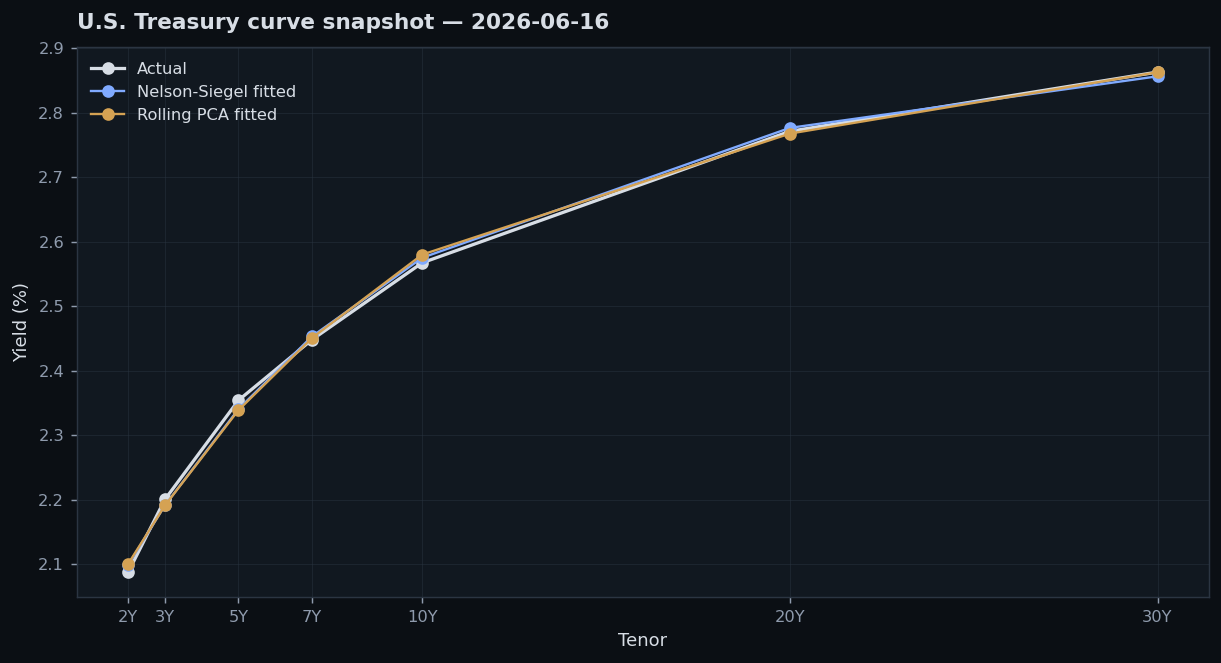

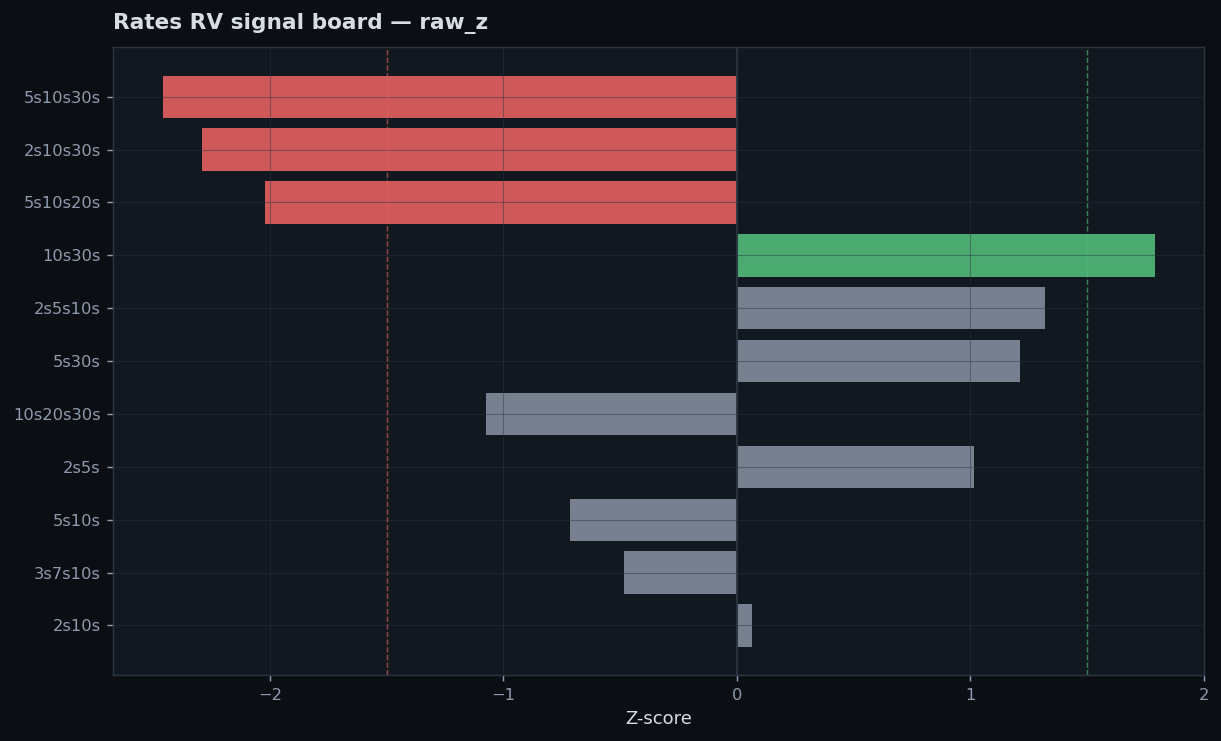

In [14]:
def format_date_axis(ax):
    ax.tick_params(axis="x", rotation=0)
    return ax


def plot_curve_snapshot():
    last = hist_yields.dropna().index[-1]
    tenors = np.array(hist_yields.columns, dtype=float)
    actual = hist_yields.loc[last].values
    ns_fit = ns_fitted_yields.loc[last].values
    pca_fit = pca_fitted_yields.loc[last].values

    fig, ax = plt.subplots(figsize=(9.5, 5.2))
    ax.plot(tenors, actual, marker="o", linewidth=1.8, color=TRADER["line"], label="Actual")
    ax.plot(tenors, ns_fit, marker="o", linewidth=1.3, color=TRADER["line2"], label="Nelson-Siegel fitted")
    if np.isfinite(pca_fit).all():
        ax.plot(tenors, pca_fit, marker="o", linewidth=1.3, color=TRADER["line3"], label="Rolling PCA fitted")
    style_ax(ax, title=f"U.S. Treasury curve snapshot — {last.date()}", ylabel="Yield (%)", xlabel="Tenor")
    ax.xaxis.set_major_locator(mticker.FixedLocator(tenors))
    ax.set_xticklabels([f"{int(t)}Y" for t in tenors])
    ax.legend(loc="best", frameon=False)
    plt.tight_layout()
    return fig


def plot_signal_board(signal_table: pd.DataFrame, metric="raw_z", top_n: int = 12):
    df = signal_table.copy()
    df["abs_metric"] = df[metric].abs()
    df = df.sort_values("abs_metric", ascending=True).tail(top_n)

    colors = []
    for z in df[metric]:
        if z >= ZSCORE_THRESHOLD:
            colors.append(TRADER["cheap"])
        elif z <= -ZSCORE_THRESHOLD:
            colors.append(TRADER["rich"])
        else:
            colors.append(TRADER["neutral"])

    fig, ax = plt.subplots(figsize=(9.5, 5.8))
    ax.barh(df.index, df[metric], color=colors, alpha=0.92)
    ax.axvline(0, color=TRADER["grid"], linewidth=1.0)
    ax.axvline(ZSCORE_THRESHOLD, color=TRADER["cheap"], linewidth=0.8, linestyle="--", alpha=0.65)
    ax.axvline(-ZSCORE_THRESHOLD, color=TRADER["rich"], linewidth=0.8, linestyle="--", alpha=0.65)
    style_ax(ax, title=f"Rates RV signal board — {metric}", ylabel=None, xlabel="Z-score")
    plt.tight_layout()
    return fig


def plot_trade_dashboard(trade: str, lookback_days: int = 504):
    if trade not in ALL_TRADES:
        raise KeyError(f"Unknown trade {trade}. Available: {list(ALL_TRADES)}")

    x_bps = trade_values_bps[trade].dropna().tail(lookback_days)
    z_raw = rolling_zscore(trade_values[trade], ROLLING_WINDOW).reindex(x_bps.index)
    z_ns = rolling_zscore(ns_residuals[trade], ROLLING_WINDOW).reindex(x_bps.index)
    z_pca = rolling_zscore(pca_residuals[trade], ROLLING_WINDOW).reindex(x_bps.index)
    ns_res_bps = ns_residuals_bps[trade].reindex(x_bps.index)
    pca_res_bps = pca_residuals_bps[trade].reindex(x_bps.index)

    roll_bps = rolldown_proxy_bps[trade].reindex(x_bps.index)

    mu = trade_values_bps[trade].rolling(ROLLING_WINDOW).mean().shift(1).reindex(x_bps.index)
    sig = trade_values_bps[trade].rolling(ROLLING_WINDOW).std().shift(1).reindex(x_bps.index)

    fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True, gridspec_kw={"height_ratios": [2.2, 1.2, 1.2, 1.2]})

    ax = axes[0]
    ax.plot(x_bps.index, x_bps, color=TRADER["line"], linewidth=1.3, label=f"{trade} value")
    ax.plot(mu.index, mu, color=TRADER["line2"], linewidth=1.0, alpha=0.9, label="Rolling mean")
    ax.fill_between(mu.index, mu - 2*sig, mu + 2*sig, color=TRADER["band"], alpha=0.35, label="±2σ band")
    style_ax(ax, title=f"{trade} — spread/fly level", ylabel="bps")
    ax.legend(loc="best", frameon=False, ncol=3)

    ax = axes[1]
    ax.plot(z_raw.index, z_raw, color=TRADER["line"], linewidth=1.1, label="Raw z")
    ax.axhline(0, color=TRADER["grid"], linewidth=0.9)
    ax.axhline(2, color=TRADER["cheap"], linestyle="--", linewidth=0.8, alpha=0.7)
    ax.axhline(-2, color=TRADER["rich"], linestyle="--", linewidth=0.8, alpha=0.7)
    style_ax(ax, title="Raw z-score", ylabel="z")

    ax = axes[2]
    ax.plot(ns_res_bps.index, ns_res_bps, color=TRADER["line2"], linewidth=1.05, label="NS residual")
    ax.plot(pca_res_bps.index, pca_res_bps, color=TRADER["line3"], linewidth=1.05, label="PCA residual")
    ax.axhline(0, color=TRADER["grid"], linewidth=0.9)
    style_ax(ax, title="Model residuals", ylabel="bps")
    ax.legend(loc="best", frameon=False, ncol=2)

    ax = axes[3]
    ax.plot(z_ns.index, z_ns, color=TRADER["line2"], linewidth=1.0, label="NS residual z")
    ax.plot(z_pca.index, z_pca, color=TRADER["line3"], linewidth=1.0, label="PCA residual z")
    ax.axhline(0, color=TRADER["grid"], linewidth=0.9)
    ax.axhline(ZSCORE_THRESHOLD, color=TRADER["cheap"], linestyle="--", linewidth=0.8, alpha=0.65)
    ax.axhline(-ZSCORE_THRESHOLD, color=TRADER["rich"], linestyle="--", linewidth=0.8, alpha=0.65)
    style_ax(ax, title=f"Model agreement z-scores | latest roll proxy: {roll_bps.dropna().iloc[-1]:.2f} bps / {ROLLDOWN_HORIZON_MONTHS}m", ylabel="z")
    ax.legend(loc="best", frameon=False, ncol=2)

    plt.tight_layout()
    return fig


def plot_mean_reversion(trade: str, signal_kind: str = "raw", horizon: int = 5):
    if signal_kind == "raw":
        sig = rolling_zscore(trade_values[trade], ROLLING_WINDOW)
    elif signal_kind == "ns":
        sig = rolling_zscore(ns_residuals[trade], ROLLING_WINDOW)
    elif signal_kind == "pca":
        sig = rolling_zscore(pca_residuals[trade], ROLLING_WINDOW)
    else:
        raise ValueError("signal_kind must be raw, ns, or pca")

    x = trade_values[trade]
    fwd_change = x.shift(-horizon) - x
    convergence_bps = (-np.sign(sig) * fwd_change * 100).dropna()
    active = sig.abs() >= ZSCORE_THRESHOLD
    active_conv = convergence_bps[active.reindex(convergence_bps.index).fillna(False)]

    fig, ax = plt.subplots(figsize=(9.5, 5.2))
    if len(active_conv) > 0:
        ax.hist(active_conv, bins=30, color=TRADER["line2"], alpha=0.75, edgecolor=TRADER["panel"])
        ax.axvline(0, color=TRADER["text"], linewidth=1.0)
        ax.axvline(active_conv.mean(), color=TRADER["line3"], linewidth=1.3, label=f"Mean: {active_conv.mean():.2f} bps")
        ax.legend(frameon=False)
    style_ax(ax, title=f"{trade} — {horizon}D convergence after |{signal_kind} z| ≥ {ZSCORE_THRESHOLD}", ylabel="Count", xlabel="Convergence, bps")
    plt.tight_layout()
    return fig

# Main charts
fig = plot_curve_snapshot()
plt.show()

fig = plot_signal_board(signal_table, metric="raw_z")
plt.show()

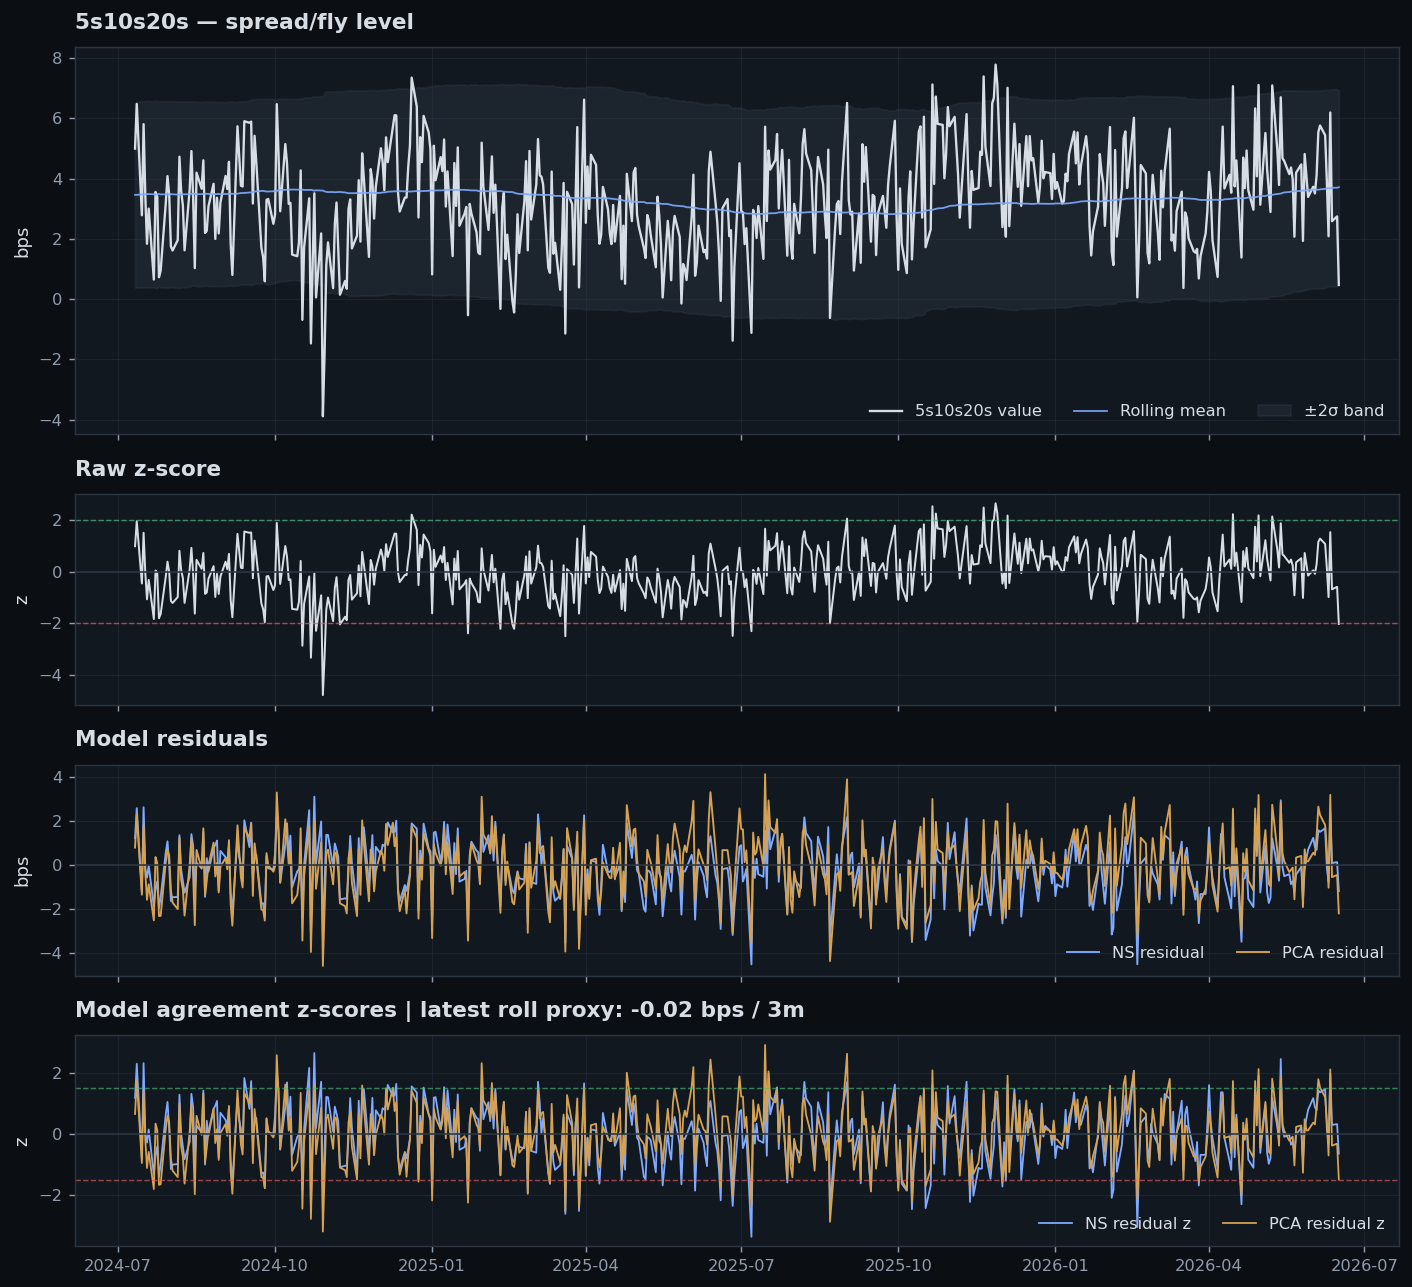

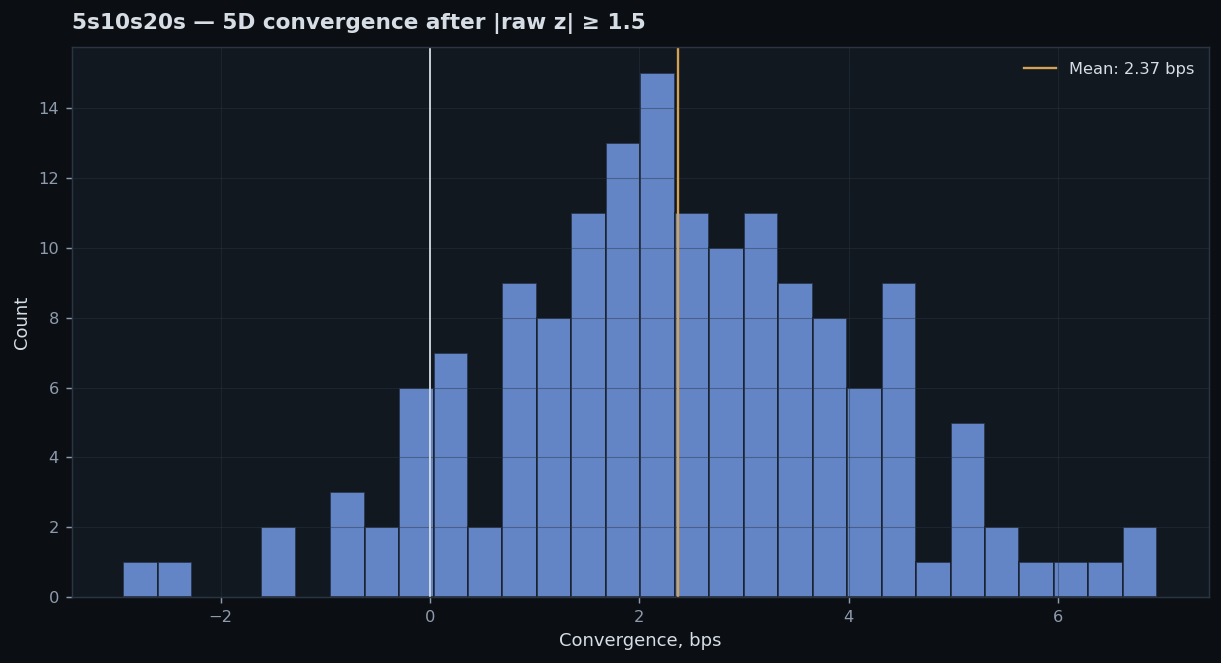

,horizon_days,n_signals,hit_rate,avg_convergence_bps,median_convergence_bps,signal_future_corr,ecm_beta,ecm_tstat,ecm_r2
0,5,157,0.9045,2.3729,2.2497,0.6274,-0.0128,-21.1605,0.3936
1,10,157,0.9363,2.5201,2.4271,0.6345,-0.0132,-23.7812,0.4027
2,20,157,0.9045,2.6927,2.7077,0.6419,-0.0135,-21.4302,0.4121


In [15]:
# Choose trades to inspect here.
# Examples: "2s5s", "2s10s", "5s10s20s", "5s10s30s"
TRADE_TO_INSPECT = "5s10s20s"

fig = plot_trade_dashboard(TRADE_TO_INSPECT, lookback_days=504)
plt.show()

fig = plot_mean_reversion(TRADE_TO_INSPECT, signal_kind="raw", horizon=5)
plt.show()

display(mean_reversion_stats(trade_values[TRADE_TO_INSPECT], rolling_zscore(trade_values[TRADE_TO_INSPECT], ROLLING_WINDOW), HORIZONS, ZSCORE_THRESHOLD))

## 11. Final desk-style summary table

This table is intentionally designed to read like a trader-screen blotter, not an academic output.

In [16]:
def add_mean_reversion_to_signal_table(signal_table: pd.DataFrame, horizon: int = 5, signal_kind: str = "raw") -> pd.DataFrame:
    mr = mean_reversion_summary_for_all(signal_kind).xs(horizon, level="horizon_days")
    mr = mr.reset_index().set_index("trade")
    out = signal_table.copy()
    out[f"{horizon}d_hit_rate"] = mr["hit_rate"]
    out[f"{horizon}d_avg_conv_bps"] = mr["avg_convergence_bps"]
    out[f"{horizon}d_corr"] = mr["signal_future_corr"]
    out[f"{horizon}d_ecm_beta"] = mr["ecm_beta"]
    out[f"{horizon}d_ecm_tstat"] = mr["ecm_tstat"]
    return out

final_board = add_mean_reversion_to_signal_table(signal_table, horizon=5, signal_kind="raw")

cols = [
    "type", "value_bps", "raw_z", "robust_z", "percentile",
    "ns_resid_bps", "ns_z", "pca_resid_bps", "pca_z",
    f"{ROLLDOWN_HORIZON_MONTHS}m_roll_bps", "liquidity_penalty_bps", "repo_specialness_overlay",
    "auction_window", "5d_hit_rate", "5d_avg_conv_bps", "5d_corr", "5d_ecm_beta", "5d_ecm_tstat", "label"
]

styled = final_board[cols].style.format({
    "value_bps": "{:.2f}",
    "raw_z": "{:.2f}",
    "robust_z": "{:.2f}",
    "percentile": "{:.0f}",
    "ns_resid_bps": "{:.2f}",
    "ns_z": "{:.2f}",
    "pca_resid_bps": "{:.2f}",
    "pca_z": "{:.2f}",
    f"{ROLLDOWN_HORIZON_MONTHS}m_roll_bps": "{:.2f}",
    "liquidity_penalty_bps": "{:.3f}",
    "repo_specialness_overlay": "{:.3f}",
    "5d_hit_rate": "{:.0%}",
    "5d_avg_conv_bps": "{:.2f}",
    "5d_corr": "{:.2f}",
    "5d_ecm_beta": "{:.4f}",
    "5d_ecm_tstat": "{:.2f}",
})

display(styled)

,type,value_bps,raw_z,robust_z,percentile,ns_resid_bps,ns_z,pca_resid_bps,pca_z,3m_roll_bps,liquidity_penalty_bps,repo_specialness_overlay,auction_window,5d_hit_rate,5d_avg_conv_bps,5d_corr,5d_ecm_beta,5d_ecm_tstat,label
trade,,,,,,,,,,,,,,,,,,,
2s5s10s,curve,2.66,1.32,1.28,92,2.31,1.71,2.81,1.91,0.45,0.400,nan,False,93%,2.56,0.70,-0.0143,-36.80,Watch only / models do not agree
3s7s10s,curve,6.42,-0.49,-0.47,29,-0.57,-0.29,-0.09,-0.12,0.72,0.400,nan,False,94%,2.72,0.70,-0.0144,-33.71,Watch only / models do not agree
10s20s30s,curve,5.60,-1.07,-1.05,14,-0.47,-0.75,0.98,0.77,0.27,0.400,nan,False,88%,2.25,0.60,-0.0125,-18.99,Watch only / models do not agree
5s10s20s,curve,0.47,-2.02,-1.96,2,-1.20,-0.65,-2.21,-1.50,-0.02,0.400,nan,False,90%,2.37,0.63,-0.0128,-21.16,Watch only / models do not agree
2s10s30s,curve,9.20,-2.29,-1.73,0,-0.56,-0.59,-0.64,-0.59,0.67,0.400,nan,False,79%,2.05,0.41,-0.0099,-8.34,Watch only / models do not agree
5s10s30s,curve,-4.12,-2.46,-2.05,0,-1.79,-1.55,-2.05,-1.64,-0.06,0.400,nan,False,77%,1.82,0.40,-0.0096,-8.29,Belly rich vs wings; short/pay belly candidate
10s30s,spread,29.57,1.79,1.50,99,1.44,1.71,1.29,1.31,0.70,0.400,nan,False,65%,1.88,0.28,-0.0108,-4.91,Watch only / models do not agree
5s30s,spread,50.89,1.21,1.06,88,-0.71,-0.48,-1.51,-1.44,1.26,0.400,nan,False,64%,2.17,0.26,-0.0106,-4.68,Watch only / models do not agree
2s5s,spread,26.65,1.02,0.92,86,2.48,1.97,2.81,1.78,1.47,0.400,nan,False,90%,2.89,0.61,-0.0141,-21.06,Watch only / models do not agree


## 12. How to read the signals

### Spreads

For a slope spread such as:

\[
2s5s = y_5 - y_2
\]

- **High positive z-score**: curve segment is unusually steep. The longer tenor is cheap relative to the shorter tenor. Mean-reversion expression is usually a **flattener**.
- **Low negative z-score**: curve segment is unusually flat. The longer tenor is rich relative to the shorter tenor. Mean-reversion expression is usually a **steepener**.

### Curve trades / butterflies

For a fly such as:

\[
5s10s20s = y_{10} - \frac{1}{2}y_5 - \frac{1}{2}y_{20}
\]

- **High positive residual/z-score**: belly yield is high versus wings, so the belly is **cheap**.
- **Low negative residual/z-score**: belly yield is low versus wings, so the belly is **rich**.

### Why agreement matters

The notebook's conservative label requires agreement across:

1. raw z-score,
2. Nelson-Siegel residual z-score,
3. PCA residual z-score.

This avoids overreacting to a single unstable model.

### What to check before trusting a trade

A good desk-quality RV candidate should have:

- extreme but not stale z-score,
- model agreement,
- favorable or at least not punitive roll/carry,
- mean-reversion evidence,
- acceptable bid/ask and liquidity,
- no obvious repo-specialness contradiction,
- no auction/supply explanation that fully justifies the move.

## 13. Production upgrades

Good next upgrades once the notebook is working on Bloomberg:

1. Replace generic yield indices with **cash Treasury CUSIPs** and compute true DV01-neutral flies.
2. Add **actual carry/roll** using cashflows, settlement dates, coupons, repo financing, and forward settlement.
3. Add **futures basis / CTD** for TY, FV, US, WN contracts.
4. Add **auction event study** around issue/reopening dates using high yield, WI yield, bid-to-cover, dealer/direct/indirect takedown, and tail/stop-through.
5. Add **macro fair-value regressions** using Fed pricing, SOFR futures, breakevens, real yields, VIX, oil, and swap spreads.
6. Save daily signal snapshots to a local parquet file so you can track model stability over the internship.